# Étape 1 — Pricing Monte Carlo sous Black-Scholes (call & put européens)

Sous la probabilité risque-neutre $\mathbb{Q}$ :
$$dS_t = r S_t\,dt + \sigma S_t\,dW_t, \qquad S_T = S_0 \exp\big((r - \tfrac{\sigma^2}{2})T + \sigma\sqrt{T}\,Z\big),\quad Z\sim\mathcal N(0,1)$$
Prix d'un payoff européen $h$ : $\;V_0 = e^{-rT}\,\mathbb{E}_{\mathbb Q}[h(S_T)]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## 1. Payoffs

In [2]:
def call_payoff(ST, K):
    """Payoff d'un call : (S_T - K)^+"""
    return np.maximum(ST - K, 0.0)


def put_payoff(ST, K):
    """Payoff d'un put : (K - S_T)^+"""
    return np.maximum(K - ST, 0.0)

## 2. Formules fermées de Black-Scholes (références pour valider le Monte Carlo)

In [3]:
def _d1_d2(S0, K, T, r, sigma):
    """Calcule d1 (= d+) et d2 (= d-), communs au call et au put."""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def bs_call_price(S0, K, T, r, sigma):
    """C = S0 N(d1) - K e^{-rT} N(d2)"""
    d1, d2 = _d1_d2(S0, K, T, r, sigma)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_put_price(S0, K, T, r, sigma):
    """P = K e^{-rT} N(-d2) - S0 N(-d1)"""
    d1, d2 = _d1_d2(S0, K, T, r, sigma)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

## 3. Simulation et moteur Monte Carlo générique

In [4]:
def simulate_terminal_prices(S0, T, r, sigma, n_paths, rng):
    """Simulation EXACTE de S_T sous Q (pas de discrétisation)."""
    Z = rng.standard_normal(n_paths)
    return S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)


def mc_price(payoff, S0, K, T, r, sigma, n_paths, seed=None, alpha=0.05):
    """
    Estimateur Monte Carlo de e^{-rT} E[payoff(S_T, K)] sous Black-Scholes.
    Renvoie (prix estimé, erreur standard, intervalle de confiance à 1-alpha).
    """
    rng = np.random.default_rng(seed)
    ST = simulate_terminal_prices(S0, T, r, sigma, n_paths, rng)
    discounted_payoffs = np.exp(-r * T) * payoff(ST, K)

    price = discounted_payoffs.mean()
    std_error = discounted_payoffs.std(ddof=1) / np.sqrt(n_paths)  # sigma_Y_hat / sqrt(N)
    z = norm.ppf(1 - alpha / 2)                                     # 1.96 pour alpha = 5 %
    return price, std_error, (price - z * std_error, price + z * std_error)

## 4. Étude de convergence

In [5]:
def convergence_study(payoff, exact, params, label, Ns=None, seed=42):
    """Affiche le tableau de convergence et renvoie les erreurs standard."""
    if Ns is None:
        Ns = [10**k for k in range(2, 8)]

    print(f"{label} — prix Black-Scholes exact : {exact:.4f}\n")
    print(f"{'N':>10} {'Prix MC':>9} {'Err. std':>9} {'IC 95%':>20} {'Exact dans IC':>14}")

    std_errors = []
    for n in Ns:
        price, se, (lo, hi) = mc_price(payoff, **params, n_paths=n, seed=seed)
        std_errors.append(se)
        print(f"{n:>10} {price:>9.4f} {se:>9.4f}   [{lo:7.4f}, {hi:7.4f}] {str(lo <= exact <= hi):>14}")
    print()
    return np.array(Ns, dtype=float), np.array(std_errors)


params = dict(S0=100.0, K=100.0, T=1.0, r=0.03, sigma=0.2)

Ns, se_call = convergence_study(call_payoff, bs_call_price(**params), params, "Call")
_,  se_put  = convergence_study(put_payoff,  bs_put_price(**params),  params, "Put")

Call — prix Black-Scholes exact : 9.4134

         N   Prix MC  Err. std               IC 95%  Exact dans IC
       100    6.7963    0.9448   [ 4.9447,  8.6480]          False
      1000    8.8811    0.4293   [ 8.0398,  9.7225]           True
     10000    9.3130    0.1416   [ 9.0355,  9.5906]           True
    100000    9.3875    0.0449   [ 9.2996,  9.4754]           True
   1000000    9.4161    0.0141   [ 9.3884,  9.4438]           True
  10000000    9.4109    0.0045   [ 9.4022,  9.4197]           True

Put — prix Black-Scholes exact : 6.4580

         N   Prix MC  Err. std               IC 95%  Exact dans IC
       100    5.6444    0.7942   [ 4.0878,  7.2010]           True
      1000    6.5515    0.3012   [ 5.9612,  7.1418]           True
     10000    6.5373    0.0948   [ 6.3516,  6.7230]           True
    100000    6.5008    0.0297   [ 6.4426,  6.5590]           True
   1000000    6.4569    0.0094   [ 6.4385,  6.4752]           True
  10000000    6.4555    0.0030   [ 6.4497,  6

## 5. Graphique : décroissance de l'erreur standard en $1/\sqrt{N}$

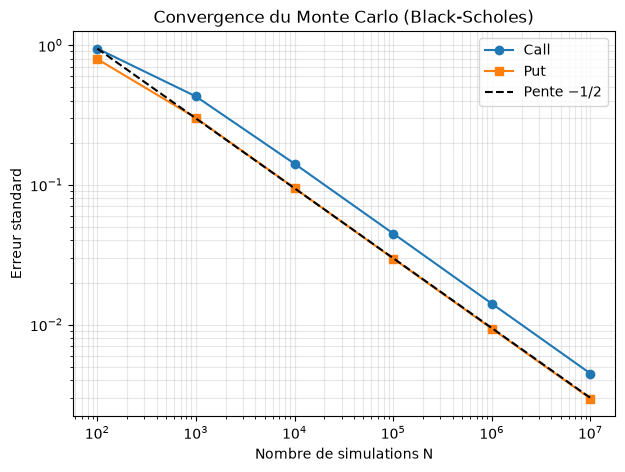

In [6]:
plt.figure(figsize=(7, 5))
plt.loglog(Ns, se_call, "o-", label="Call")
plt.loglog(Ns, se_put, "s-", label="Put")
plt.loglog(Ns, se_call[0] * np.sqrt(Ns[0] / Ns), "k--", label=r"Pente $-1/2$")
plt.xlabel("Nombre de simulations N")
plt.ylabel("Erreur standard")
plt.title("Convergence du Monte Carlo (Black-Scholes)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("convergence_call_put.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Vérification de la parité call-put : $C - P = S_0 - K e^{-rT}$

On vérifie d'abord les formules fermées, puis le Monte Carlo (avec la même graine pour le call et le put).

In [7]:
parity_exact = params["S0"] - params["K"] * np.exp(-params["r"] * params["T"])

# Formules fermées : l'égalité doit être vraie à la précision machine
C, P = bs_call_price(**params), bs_put_price(**params)
print(f"Formules fermées : C - P = {C - P:.6f}   |   S0 - K e^(-rT) = {parity_exact:.6f}\n")

# Monte Carlo
print(f"{'N':>10} {'C - P (MC)':>11} {'Écart':>9}")
for n in [10**k for k in range(3, 8)]:
    c_mc, _, _ = mc_price(call_payoff, **params, n_paths=n, seed=42)
    p_mc, _, _ = mc_price(put_payoff,  **params, n_paths=n, seed=42)
    print(f"{n:>10} {c_mc - p_mc:>11.4f} {c_mc - p_mc - parity_exact:>9.4f}")

Formules fermées : C - P = 2.955447   |   S0 - K e^(-rT) = 2.955447

         N  C - P (MC)     Écart
      1000      2.3296   -0.6258
     10000      2.7757   -0.1797
    100000      2.8867   -0.0687
   1000000      2.9592    0.0038
  10000000      2.9554   -0.0001
